# M4d — KWIC Analysis + Topic Modeling

1. **KWIC (Keyword-in-Context)**: Extend the "peoples" contextual analysis to other thesis-critical terms
2. **Topic Modeling**: BERTopic with pre-computed Voyage embeddings
3. **Cross-constitutional similarity network**

In [1]:
import json
import re
import sys
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *

apply_style()

PROJECT = Path('..') if Path('../src/data.js').exists() else Path('.')
CORPUS_DIR = PROJECT / 'data' / 'constitution_corpus'

with open(PROJECT / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))
with open(PROJECT / 'scripts' / 'country_mapping.json') as f:
    EN_TO_FR = json.load(f)
with open(PROJECT / 'scripts' / 'post_conflict_coding.json') as f:
    pc_coding = json.load(f)

heritage_map = DATA['colonial_heritage']
def get_heritage(en): return heritage_map.get(EN_TO_FR.get(en, en), 'other')
def get_pc(en):
    fr = EN_TO_FR.get(en, en)
    info = pc_coding.get(fr, {})
    return info.get('post_conflict', False) if isinstance(info, dict) else bool(info)

# Load texts
stats = json.load(open(CORPUS_DIR / '_extraction_stats.json'))
texts = {}
for s in stats:
    texts[s['country']] = (CORPUS_DIR / f"{Path(s['file']).stem}.txt").read_text(encoding='utf-8')

print(f'Loaded {len(texts)} constitutions')

Loaded 54 constitutions


> **Translation caveat:** KWIC analysis operates on English translations. Cross-heritage frequency differences in keyword contexts may partly reflect translation artifacts rather than substantive constitutional differences. See `docs/linguistic_decisions.md`.

## 1. KWIC — Keyword-in-Context Analysis

For each thesis-critical term, extract ALL occurrences with surrounding context (±80 chars), classify the context, and compare across heritage groups.

In [2]:
def kwic_extract(texts_dict, keyword, window=80):
    """Extract keyword-in-context with heritage and post-conflict metadata."""
    results = []
    for country, text in texts_dict.items():
        text_lower = text.lower()
        h = get_heritage(country)
        pc = get_pc(country)
        for m in re.finditer(r'\b' + re.escape(keyword) + r'\b', text_lower):
            start = max(0, m.start() - window)
            end = min(len(text), m.end() + window)
            ctx = ' '.join(text[start:end].split())
            results.append({'country': country, 'heritage': h, 'post_conflict': pc, 'context': ctx})
    return results

# Analyze key terms
TERMS = ['indigenous', 'autonomy', 'customary', 'traditional', 'minority', 'ethnic', 'tribe']

kwic_summary = []
for term in TERMS:
    results = kwic_extract(texts, term)
    total = len(results)
    by_h = Counter(r['heritage'] for r in results)
    by_pc = Counter(r['post_conflict'] for r in results)
    kwic_summary.append({
        'term': term, 'total': total,
        'francophone': by_h.get('francophone', 0),
        'anglophone': by_h.get('anglophone', 0),
        'lusophone': by_h.get('lusophone', 0),
        'post_conflict': by_pc.get(True, 0),
        'non_conflict': by_pc.get(False, 0),
    })
    print(f'{term:15s}: {total:4d} occurrences (franco={by_h.get("francophone",0):3d}, anglo={by_h.get("anglophone",0):3d}, post-conf={by_pc.get(True,0):3d})')

ks = pd.DataFrame(kwic_summary)

indigenous     :   45 occurrences (franco=  3, anglo= 38, post-conf= 30)


autonomy       :   70 occurrences (franco= 29, anglo=  5, post-conf= 31)
customary      :  278 occurrences (franco= 31, anglo=220, post-conf= 78)


traditional    :  259 occurrences (franco= 42, anglo=191, post-conf=143)


minority       :   21 occurrences (franco=  3, anglo= 15, post-conf= 18)


ethnic         :  193 occurrences (franco= 80, anglo= 92, post-conf= 97)


tribe          :   54 occurrences (franco= 11, anglo= 33, post-conf= 17)


In [3]:
# KWIC deep dive: "indigenous" — how is it used?
indigenous_contexts = kwic_extract(texts, 'indigenous')

def classify_indigenous(ctx):
    c = ctx.lower()
    if re.search(r'indigenous people|indigenous communit|indigenous group|indigenous population', c):
        return 'Indigenous peoples/communities'
    if re.search(r'indigenous language|indigenous knowledge|indigenous culture', c):
        return 'Indigenous culture/language'
    if re.search(r'indigenous law|indigenous court|indigenous justice', c):
        return 'Indigenous legal system'
    if re.search(r'indigenous plant|indigenous resource|indigenous species', c):
        return 'Natural resources'
    return 'Other'

for item in indigenous_contexts:
    item['context_type'] = classify_indigenous(item['context'])

ig = pd.DataFrame(indigenous_contexts)
if len(ig) > 0:
    print('"indigenous" context types:')
    print(ig['context_type'].value_counts())
    print()
    print('By heritage:')
    print(pd.crosstab(ig['heritage'], ig['context_type']))
    print()
    print('Sample contexts:')
    for _, row in ig.head(10).iterrows():
        fr_name = EN_TO_FR.get(row['country'], row['country'])
        print(f'  [{fr_name:20s}] ({row["context_type"]}) ...{row["context"][:100]}...')

"indigenous" context types:
context_type
Other                             27
Indigenous peoples/communities     9
Indigenous culture/language        7
Indigenous legal system            2
Name: count, dtype: int64

By heritage:
context_type  Indigenous culture/language  Indigenous legal system  \
heritage                                                             
anglophone                              7                        2   
francophone                             0                        0   
lusophone                               0                        0   
mixed                                   0                        0   

context_type  Indigenous peoples/communities  Other  
heritage                                             
anglophone                                 8     21  
francophone                                0      3  
lusophone                                  0      3  
mixed                                      1      0  

Sample contexts:
  [Angol

"customary" context types:
context_type
Customary law/courts     186
International law         38
Other                     34
Land/property rights       8
Traditional authority      6
Cultural practices         6
Name: count, dtype: int64

By heritage:
context_type  Cultural practices  Customary law/courts  International law  \
heritage                                                                    
anglophone                     3                   172                 22   
francophone                    0                     3                  3   
lusophone                      0                     5                 11   
other                          3                     6                  2   

context_type  Land/property rights  Other  Traditional authority  
heritage                                                          
anglophone                       7     16                      0  
francophone                      1     18                      6  
lusophone      

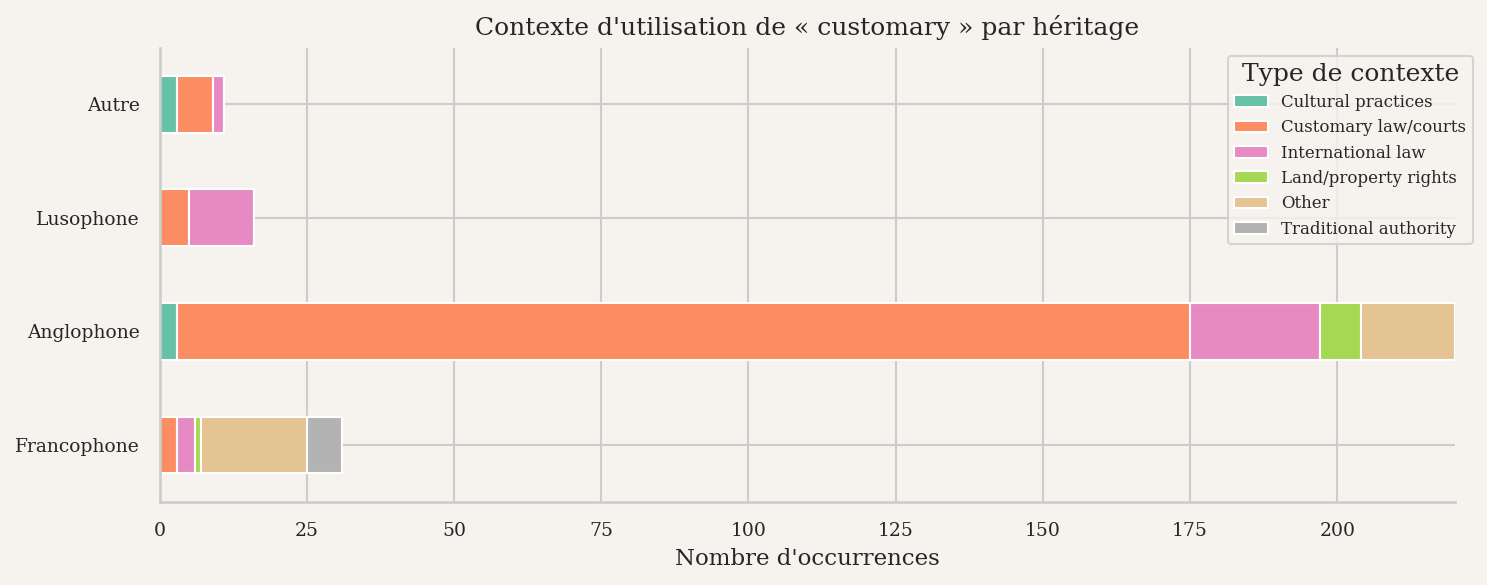

In [4]:
# KWIC deep dive: "customary" — customary law vs customary practice
customary_contexts = kwic_extract(texts, 'customary')

def classify_customary(ctx):
    c = ctx.lower()
    if re.search(r'customary law|customary court|customary justice|customary tribunal', c):
        return 'Customary law/courts'
    if re.search(r'customary leader|customary chief|customary authority|customary ruler', c):
        return 'Traditional authority'
    if re.search(r'customary right|customary tenure|customary land', c):
        return 'Land/property rights'
    if re.search(r'customary practice|customary marriage|customary rite', c):
        return 'Cultural practices'
    if re.search(r'customary international', c):
        return 'International law'
    return 'Other'

for item in customary_contexts:
    item['context_type'] = classify_customary(item['context'])

cu = pd.DataFrame(customary_contexts)
if len(cu) > 0:
    print('"customary" context types:')
    print(cu['context_type'].value_counts())
    print()
    ct = pd.crosstab(cu['heritage'], cu['context_type'])
    print('By heritage:')
    print(ct)

    # FIGURE: customary context by heritage
    ct_plot = ct.reindex(index=[h for h in H_ORDER if h in ct.index])

    for lang in ('fr', 'en'):
        fig, ax = plt.subplots(figsize=(10, 4))
        ct_display = ct_plot.copy()
        ct_display.index = [hl(h, lang) for h in ct_display.index]
        ct_display.plot(kind='barh', stacked=True, ax=ax, colormap='Set2')
        ax.set_xlabel(t('kwic_xlabel', lang))
        ax.set_title(t('kwic_customary_title', lang), fontsize=12)
        ax.legend(title=t('kwic_legend', lang), bbox_to_anchor=(1.02, 1), fontsize=8)
        plt.tight_layout()
        save_fig(fig, 'kwic_customary_context', lang)
        if lang == 'fr':
            plt.show()
        else:
            plt.close(fig)

## 2. Topic Modeling (BERTopic)

Use pre-computed Voyage embeddings + BERTopic to discover latent topics in the constitution corpus.

In [5]:
# Split each constitution into paragraphs for topic modeling
# (BERTopic works best on shorter documents)
paragraphs = []
para_meta = []
for country, text in texts.items():
    h = get_heritage(country)
    fr_name = EN_TO_FR.get(country, country)
    # Split on double newlines or long single newlines
    paras = re.split(r'\n{2,}', text)
    for p in paras:
        p = p.strip()
        if len(p.split()) < 15:  # skip very short paragraphs
            continue
        paragraphs.append(p)
        para_meta.append({'country': country, 'fr_name': fr_name, 'heritage': h})

print(f'Paragraphs: {len(paragraphs)} from {len(texts)} constitutions')
print(f'Mean paragraph length: {np.mean([len(p.split()) for p in paragraphs]):.0f} words')

Paragraphs: 3103 from 54 constitutions
Mean paragraph length: 461 words


> **Embedding model note:** BERTopic below uses `all-MiniLM-L6-v2` (384-dim, sentence-transformers default) for paragraph embeddings. This is *not* the same as `voyage-law-2` used for full-document embeddings in `m4_clustering_embeddings.ipynb`. The lighter model is adequate for paragraph-level topic discovery but results are not directly comparable to the full-document clustering.

In [6]:
try:
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer
    import umap
    from hdbscan import HDBSCAN

    # Use pre-computed Voyage embeddings for the full constitutions
    # For paragraphs, we need to use a lighter embedding model
    # Use TF-IDF based BERTopic (no embedding needed)
    vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))

    umap_model = umap.UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
    hdbscan_model = HDBSCAN(min_cluster_size=30, min_samples=5, prediction_data=True)

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        nr_topics='auto',
        verbose=True,
    )

    topics, probs = topic_model.fit_transform(paragraphs)

    print(f'\nTopics found: {len(set(topics)) - 1} (excluding outlier topic -1)')
    print(f'Outlier paragraphs: {topics.count(-1)}/{len(topics)}')

    # Show top topics
    topic_info = topic_model.get_topic_info()
    print('\nTop topics:')
    for _, row in topic_info.head(15).iterrows():
        print(f'  Topic {row["Topic"]:3d} (n={row["Count"]:4d}): {row["Name"]}')

    # Topic distribution by heritage
    meta_df = pd.DataFrame(para_meta)
    meta_df['topic'] = topics
    print('\nTopic distribution by heritage (top 5 topics):')
    top_topics = [tid for tid in topic_info['Topic'].head(6) if t != -1]
    for tid in top_topics:
        t_meta = meta_df[meta_df['topic'] == t]
        h_counts = t_meta['heritage'].value_counts().to_dict()
        keywords = ', '.join([w for w, _ in topic_model.get_topic(tid)[:5]])
        print(f'  Topic {t}: {keywords}')
        print(f'    Heritage: {h_counts}')

    BERTOPIC_OK = True

except ImportError as e:
    print(f'BERTopic not available: {e}')
    print('Skipping topic modeling — install with: uv add bertopic')
    BERTOPIC_OK = False

/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-21 20:24:36,405 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3347.59it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

2026-03-21 20:26:40,084 - BERTopic - Topic reduction - Reducing number of topics


2026-03-21 20:26:40,092 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-03-21 20:26:41,303 - BERTopic - Representation - Completed ✓


2026-03-21 20:26:41,305 - BERTopic - Topic reduction - Reduced number of topics from 30 to 15



Topics found: 14 (excluding outlier topic -1)
Outlier paragraphs: 664/3103

Top topics:
  Topic  -1 (n= 664): -1_shall_law_court_person
  Topic   0 (n= 934): 0_president_shall_court_assembly
  Topic   1 (n= 412): 1_shall_national_law_state
  Topic   2 (n= 402): 2_article_right_11_10
  Topic   3 (n= 124): 3_person_right_law_offence
  Topic   4 (n= 105): 4_local_provincial_government_council
  Topic   5 (n=  86): 5_fund_expenditure_year_appropriation
  Topic   6 (n=  80): 6_right_education_state_children
  Topic   7 (n=  55): 7_freedom_right_public_law
  Topic   8 (n=  51): 8_nigeria_federation_state_house
  Topic   9 (n=  44): 9_commission_zimbabwe_rights_human rights
  Topic  10 (n=  43): 10_emergency_declaration_state emergency_state
  Topic  11 (n=  43): 11_shall_namibia_bank_hereof
  Topic  12 (n=  30): 12_election_candidate_candidates_elected
  Topic  13 (n=  30): 13_defence_forces_security_defence forces

Topic distribution by heritage (top 5 topics):
  Topic <function t at 0x7bd

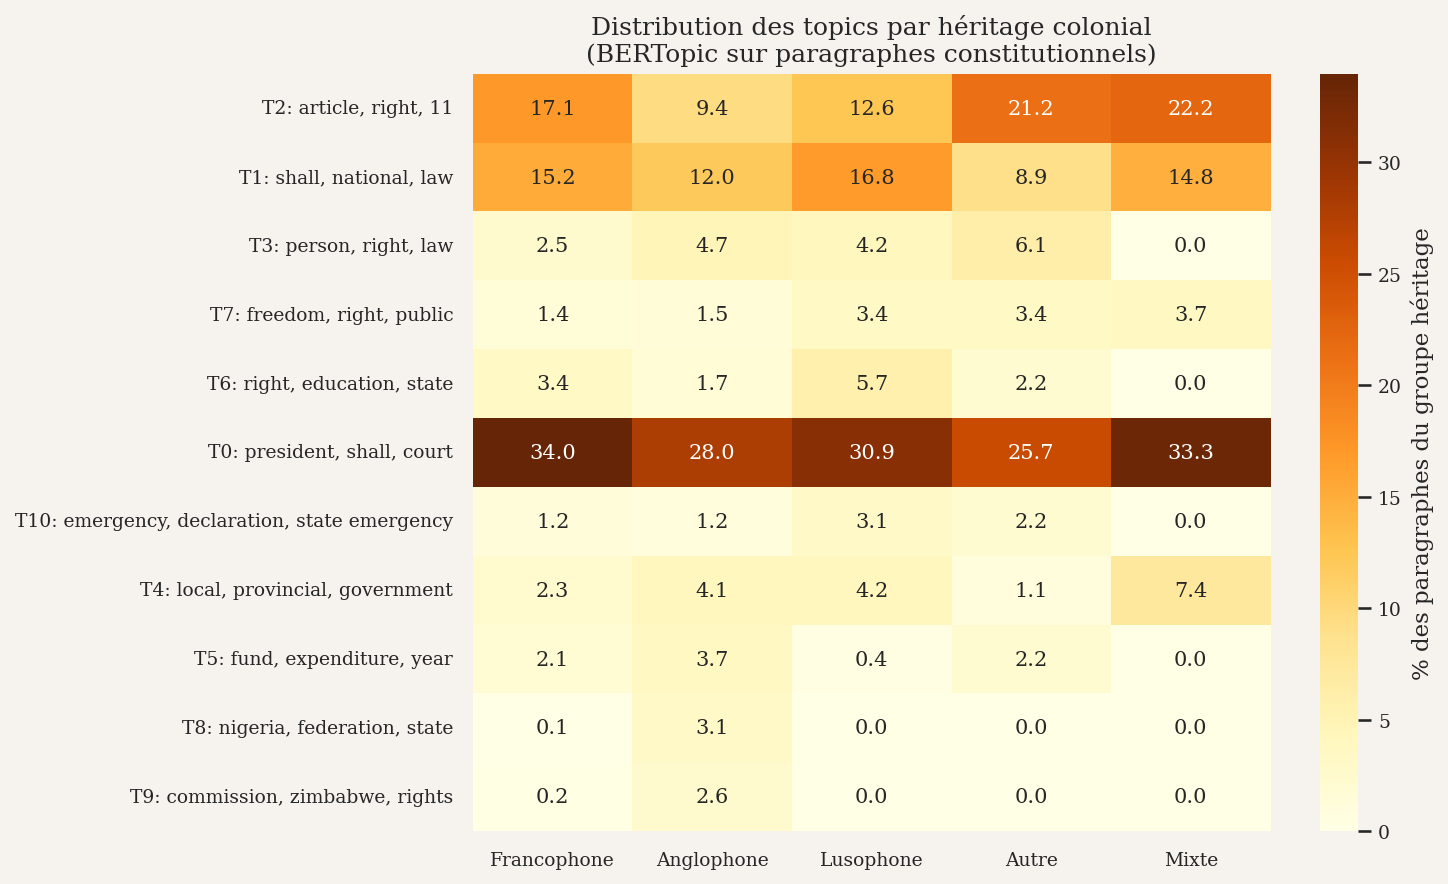

In [7]:
if BERTOPIC_OK:
    # Compute topic-heritage data once
    top_topics = [t_id for t_id in topic_info['Topic'].head(12) if t_id != -1]
    topic_heritage = defaultdict(lambda: defaultdict(int))
    for _, row in meta_df.iterrows():
        if row['topic'] in top_topics:
            topic_heritage[row['topic']][row['heritage']] += 1

    th_df = pd.DataFrame(topic_heritage).T.fillna(0)
    th_df = th_df.reindex(columns=[h for h in H_ORDER if h in th_df.columns])

    # Normalize by total paragraphs per heritage
    h_totals = meta_df['heritage'].value_counts()
    th_df_norm = th_df.copy()
    for col in th_df_norm.columns:
        th_df_norm[col] = th_df_norm[col] / h_totals.get(col, 1) * 100

    # Topic keyword labels (language-independent)
    topic_labels = {}
    for t_id in top_topics:
        keywords = ', '.join([w for w, _ in topic_model.get_topic(t_id)[:3]])
        topic_labels[t_id] = f'T{t_id}: {keywords}'

    # FIGURE: Topic x heritage heatmap
    for lang in ('fr', 'en'):
        fig, ax = plt.subplots(figsize=(10, 6))
        th_display = th_df_norm.copy()
        th_display.columns = [hl(h, lang) for h in th_display.columns]
        th_display.index = [topic_labels.get(t_id, f'T{t_id}') for t_id in th_display.index]

        sns.heatmap(th_display, annot=True, fmt='.1f', cmap='YlOrBr', ax=ax,
                    cbar_kws={'label': t('topics_cbar', lang)})
        ax.set_title(t('topics_title', lang), fontsize=12)
        ax.set_ylabel('')
        plt.tight_layout()
        save_fig(fig, 'topics_heritage_heatmap', lang)
        if lang == 'fr':
            plt.show()
        else:
            plt.close(fig)
else:
    print('Skipping topic visualization — BERTopic not available')

## 3. Summary

In [8]:
print('='*60)
print('M4d SUMMARY')
print('='*60)

print(f'\nKWIC Analysis:')
for _, row in ks.iterrows():
    print(f'  {row["term"]:15s}: {row["total"]:4d} total (franco={row["francophone"]:3d}, anglo={row["anglophone"]:3d}, post-conf={row["post_conflict"]:3d})')

if BERTOPIC_OK:
    print(f'\nBERTopic: {len(set(topics))-1} topics found from {len(paragraphs)} paragraphs')
else:
    print(f'\nBERTopic: not available (install with uv add bertopic)')

print(f'\nFigures:')
for f in sorted(FIG_DIR.glob('kwic_*')) + sorted(FIG_DIR.glob('topics_*')):
    print(f'  {f.name}')

M4d SUMMARY

KWIC Analysis:
  indigenous     :   45 total (franco=  3, anglo= 38, post-conf= 30)
  autonomy       :   70 total (franco= 29, anglo=  5, post-conf= 31)
  customary      :  278 total (franco= 31, anglo=220, post-conf= 78)
  traditional    :  259 total (franco= 42, anglo=191, post-conf=143)
  minority       :   21 total (franco=  3, anglo= 15, post-conf= 18)
  ethnic         :  193 total (franco= 80, anglo= 92, post-conf= 97)
  tribe          :   54 total (franco= 11, anglo= 33, post-conf= 17)

BERTopic: 14 topics found from 3103 paragraphs

Figures:
  kwic_customary_context.pdf
  kwic_customary_context.png
  topics_heritage_heatmap.pdf
  topics_heritage_heatmap.png
